# **ML Model Building - F1 Pitstop Prediction**

## **Problem Statement:**

- The objective of this project is to build a machine learning model that predicts whether a Formula 1 driver will make a pit stop in the next lap based on race conditions, tire performance, and lap data. 
- This helps in understanding and simulating race strategies using historical data.

## **Feature Selection:**

- Features such as `lap number`, `tire life`, `race progress`, and `lap time` metrics were selected as they directly influence pit stop decisions. 
- Columns like `Driver`, `Race`, and `Year` were removed as they act as identifiers.
- The `PitStop` column was also removed to prevent data leakage.
- The `PitNextLap` column is our Target Column

## **1. Understanding the F1 Dataset**

### **1.1 Importing all the necessary Modules**

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

### **1.2 Loading the F1 Dataset**

In [3]:
data = pd.read_csv(r'F:\Innomatics\Class\7. AI_ML\Projects\Project-1_ML_Model_Building\Dataset\f1_strategy_dataset.csv')
data.head(2)

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0


### **1.3 Data Inspecting**

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  str    
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  str    
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  str    
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife     101371 

In [4]:
data.shape

(101371, 16)

### **1.4 Checking for Null Values**

- If there is a null value in our dataset, then we will apply the correct technique to handle missing Values

In [5]:
data.isna().sum()

Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

In [6]:
data = data.dropna()

In [7]:
data.isna().sum()

Driver                    0
LapNumber                 0
Compound                  0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
Race                      0
Year                      0
LapTime_Delta             0
Cumulative_Degradation    0
PitStop                   0
PitNextLap                0
RaceProgress              0
Normalized_TyreLife       0
Position_Change           0
dtype: int64

### **1.5 Checking for Duplicated Values**

- From the below result we can see there is no duplicate values in our dataset.

In [8]:
data[data.duplicated()]

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change


### **1.6 Fixing the columns names for better readibility**

- Here we can see Column names inconsistency like `LapTime (s)` - Here, no need of `(s)`
- Also some other columns has `_` as Delimiter but we don't want this because other columns doesn't follow this pattern

In [9]:
data.head(1)

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.0,0.0,0,0,0.017241,0.117647,0.0


In [10]:
data.rename(columns={'LapTime (s)':'LapTime','LapTime_Delta':'LapTimeDelta','Cumulative_Degradation':'CumulativeDegradation','Normalized_TyreLife':'NormalizedTyreLife','Position_Change':'PositionChange'},inplace=True)

In [11]:
data.columns

Index(['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position',
       'LapTime', 'Race', 'Year', 'LapTimeDelta', 'CumulativeDegradation',
       'PitStop', 'PitNextLap', 'RaceProgress', 'NormalizedTyreLife',
       'PositionChange'],
      dtype='str')

### **1.7 Checking For Outliers**

In [12]:
data.describe()

,LapNumber,Stint,TyreLife,Position,LapTime,Year,LapTimeDelta,CumulativeDegradation,PitStop,PitNextLap,RaceProgress,NormalizedTyreLife,PositionChange
count,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000
mean,30.431302,2.045082,14.544712,9.758788,92.597575,2023.590721,-0.197137,-29.528322,0.251686,0.254588,0.432437,0.386400,-0.003721
std,18.143087,0.947369,10.312058,5.407104,33.239256,1.098126,45.356813,70.244867,0.433984,0.435631,0.258088,0.259865,3.913402
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.031000,2023.000000,-7.246000,-51.027000,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.181000,2024.000000,-0.026000,-21.663000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.362000,2025.000000,5.721000,-3.716000,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


**Removing Outliers from `LapTime` column**

In [13]:
data = data[data["LapTime"] < 300]

**Removing Outliers from `LapTimeDelta` column**

In [14]:
data = data[(data["LapTimeDelta"] > -100) & (data["LapTimeDelta"] < 100)]

**Removing Outliers from `CumulativeDegradation` column**

In [15]:
data = data[(data["CumulativeDegradation"] > -300) & (data["CumulativeDegradation"] < 300)]

In [16]:
data.describe()

,LapNumber,Stint,TyreLife,Position,LapTime,Year,LapTimeDelta,CumulativeDegradation,PitStop,PitNextLap,RaceProgress,NormalizedTyreLife,PositionChange
count,101245.000000,101245.000000,101245.000000,101245.000000,101245.000000,101245.000000,101245.000000,101245.000000,101245.000000,101245.000000,101245.000000,101245.000000,101245.000000
mean,30.448743,2.045701,14.552679,9.757963,92.204424,2023.590469,-0.187148,-29.916226,0.251785,0.254679,0.432685,0.386613,-0.003625
std,18.134306,0.947308,10.309914,5.406664,13.960803,1.098155,15.783605,63.378279,0.434041,0.435683,0.257962,0.259795,3.911926
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-99.949000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.027000,2023.000000,-7.236000,-51.041000,0.000000,0.000000,0.210526,0.173077,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.169000,2024.000000,-0.026000,-21.674000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.354000,2025.000000,5.711000,-3.731000,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,282.084000,2025.000000,96.427000,196.791000,1.000000,1.000000,1.000000,1.000000,18.000000


**Conclusion**

- Outliers were identified using summary statistics (`describe()` method).
- Columns such as LapTime, LapTimeDelta, and CumulativeDegradation showed extreme values.
- Unrealistic values were detected, such as abnormally high lap times and large fluctuations in lap time differences.
- These extreme values may occur due to pit stops, recording errors, or abnormal race conditions.
- To ensure data quality, threshold-based filtering was applied to remove such values.
- Only reasonable and realistic ranges were retained for model training.
- This step helps in improving model accuracy and preventing misleading predictions.

## **2. Exploratory Data Analysis (EDA)**

### **2.1 Countplot of PitNextLap - (Yes/No)**

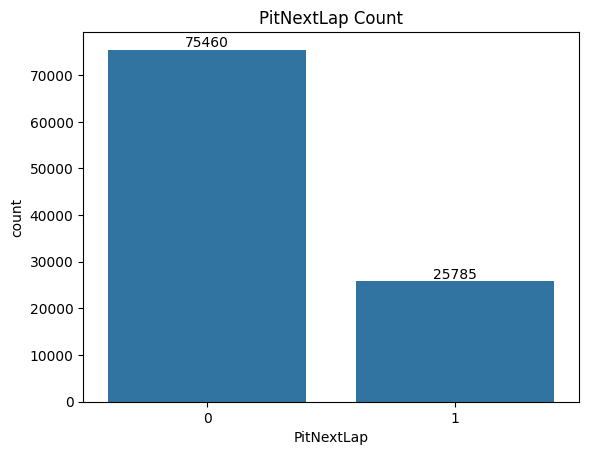

In [17]:
sns.countplot(x='PitNextLap',data=data)

plt.title("PitNextLap Count")
for i in plt.gca().containers:
    plt.bar_label(i)

**Observations**

- The distribution of the target variable was analyzed to understand class balance.
- It was observed that the dataset contains both pit (1) and non-pit (0) cases.

### **2.2 TyreLife vs PitNextLap**

Text(0, 0.5, 'Values')

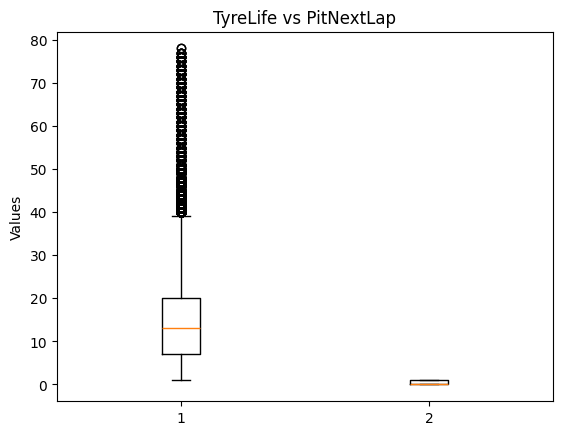

In [18]:
plt.boxplot([data.TyreLife,data.PitNextLap], label=['TyreLife','PitNextLap'])

plt.title('TyreLife vs PitNextLap')
plt.ylabel('Values')

**Observations**

- Higher tyre life tends to increase the probability of pit stops due to wear and degradation.
- Also for PitNextLap we have only two values that is either 0 or 1.

### **2.3 RaceProgress vs PitNextLap**

<Axes: xlabel='PitNextLap', ylabel='RaceProgress'>

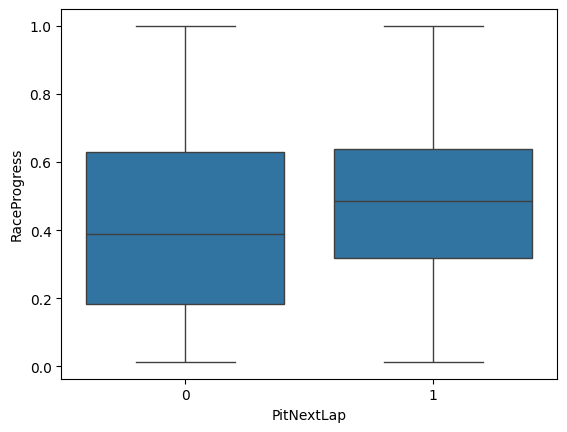

In [19]:
sns.boxplot(x=data["PitNextLap"], y=data["RaceProgress"])

**Observations**

The boxplot shows the distribution of race progress for pit and non-pit cases. It can be observed that pit stops tend to occur more frequently during the mid to later stages of the race.

### **2.4 Correlation Heatmap**

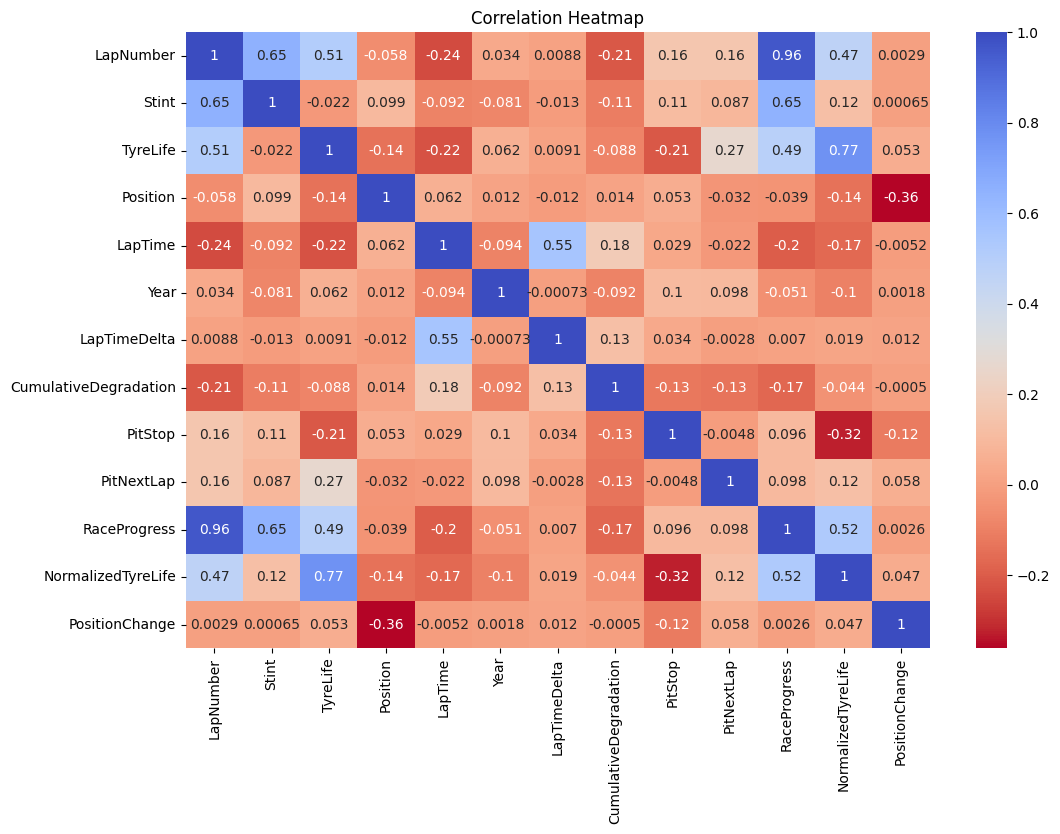

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm_r")
plt.title("Correlation Heatmap")
plt.show()

**Observations**

- A strong positive correlation (~0.96) is observed between LapNumber and RaceProgress, indicating both represent race progression.
- TyreLife and NormalizedTyreLife show a high positive correlation (~0.77), as both describe tire usage.
- Features like TyreLife (~0.27), LapNumber (~0.16), and RaceProgress (~0.09) show some correlation with PitNextLap, indicating their influence on pit stop decisions.
- LapTime and LapTimeDelta have a moderate positive correlation (~0.55), suggesting lap time variations impact overall performance.
- Position shows weak correlation with most features and the target, indicating limited influence on pit stop prediction.
- CumulativeDegradation shows a slight negative correlation (~ -0.13) with PitNextLap, indicating a minor relationship with pit decisions.
- Most features do not have very high correlation with each other, indicating low multicollinearity.

## **3. Data Preprocessing**

### **3.1 Checking For unique values present in Each Columns**

In [21]:
for i in data:
    print('*'*50,i,'*'*50)
    print(data[i].unique())

************************************************** Driver **************************************************
<StringArray>
['ALB', 'ALO', 'BOT', 'GAS', 'HAM', 'HUL', 'LEC', 'MAG', 'NOR', 'OCO', 'PER',
 'PIA', 'RIC', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'ZHO', 'DEV', 'LAW',
 'COL', 'DOO', 'BEA', 'ANT', 'BOR', 'HAD', 'LAT', 'MSC', 'VET']
Length: 31, dtype: str
************************************************** LapNumber **************************************************
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78]
************************************************** Compound **************************************************
<StringArray>
['MEDIUM', 'HARD', 'SOFT', 'INTERMEDIATE', 'WET']
Length: 5, dtype: str
************************************************** Stint *****************************

### **3.2 Dividing the Data into `X` (Input Features) and `y` (Target Variable)**

- For my X features im selecting these `LapNumber`, `Stint`, `TyreLife`, `Position`, `LapTime`, `LapTimeDelta`, `CumulativeDegradation`, `RaceProgress`, `NormalizedTyreLife`, `PositionChange`, `Compound`
- Here we are not including `Driver`, `Race`, `Year`, `Pitstop` columns because it is not necessary for our model.
- For my Target Variable I'm selecting `PitNextLap`

In [22]:
X = data.drop(columns=['Driver','Race','Year','PitStop','PitNextLap'])
y = data['PitNextLap']

### **3.3 Splitting `X` and `y` into Train and Test**

In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=1)

### **3.4 Applying Feature Engineering on `X_train`**

- Right Now our `X_train` consists of Categorical and numerical columns with data inconsistency like Scaling issue
- But before applying the techniques lets first reset the index otherwise it will create problem later when we merge the splitted dfs

In [24]:
X_train.reset_index(inplace=True)
X_train.pop('index')

0         35763
1         84381
2         88037
3         58191
4        100585
          ...  
80991     50089
80992     98173
80993      5192
80994     77759
80995     98665
Name: index, Length: 80996, dtype: int64

In [25]:
X_train

,LapNumber,Compound,Stint,TyreLife,Position,LapTime,LapTimeDelta,CumulativeDegradation,RaceProgress,NormalizedTyreLife,PositionChange
0,51,HARD,3,19.0,17,76.183,-15.346,0.090,0.662338,0.475000,-7.0
1,48,SOFT,4,9.0,3,91.628,12.915,-58.869,0.666667,0.264706,5.0
2,57,SOFT,4,4.0,8,79.231,-17.142,-42.116,0.791667,0.093023,-7.0
3,9,INTERMEDIATE,1,9.0,5,123.892,22.389,149.589,0.118421,0.169811,8.0
4,12,HARD,2,2.0,13,122.948,26.889,-8.099,0.166667,0.044444,5.0
...,...,...,...,...,...,...,...,...,...,...,...
80991,8,SOFT,1,8.0,12,82.359,-11.190,-65.685,0.105263,0.210526,-3.0
80992,26,HARD,2,10.0,5,93.968,-5.338,138.441,0.361111,0.222222,1.0
80993,25,HARD,2,10.0,8,98.250,-0.228,-21.626,0.438596,0.666667,0.0
80994,30,MEDIUM,1,30.0,7,75.705,-24.105,0.674,0.394737,0.833333,1.0


#### **3.4.1 Dividing X_train into Categorical and Numerical Dataframes to perform different operations**

- cat_xtrain_df : It will store all the categorical columns 
- num_xtrain_df : It will store all the numerical columns
- no_change_xtrain_df : It will store all the columns that doesn't require any scaling or transformation technique , but in  our dataset we need to transform all the columns

In [ ]:
cat_xtrain_df = X_train.select_dtypes(include=['str','object'])
num_xtrain_df = X_train.select_dtypes(include=['int','float'])

C:\Users\Soro\AppData\Local\Temp\ipykernel_5904\2383632237.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_xtrain_df = X_train.select_dtypes(include=['object'])


#### **3.4.2 Applying Transformation Technique in Cat_xtrain_df**

- Here we will apply Ordinal Encoding, since our data has some kind of relationship between them

In [27]:
from sklearn.preprocessing import OrdinalEncoder

OE = OrdinalEncoder().set_output(transform='pandas')

cat_xtrain_df_transf = OE.fit_transform(cat_xtrain_df)

In [28]:
cat_xtrain_df_transf.head(3)

,Compound
0,0.0
1,3.0
2,3.0


#### **3.4.3 Applying Scaling Technique in num_xtrain_df**

- Here we will apply MinMaxScaling method, because right now our data is in numerical but the scaling is different for each and every columns
- To pass this through Algorithm we want to make all the columns in same scale

In [29]:
from sklearn.preprocessing import MinMaxScaler

Scaler = MinMaxScaler().set_output(transform='pandas')

num_xtrain_df_transf = Scaler.fit_transform(num_xtrain_df)

In [30]:
num_xtrain_df_transf.head(3)

,LapNumber,Stint,TyreLife,Position,LapTime,LapTimeDelta,CumulativeDegradation,RaceProgress,NormalizedTyreLife,PositionChange
0,0.649351,0.285714,0.233766,0.842105,0.042642,0.430821,0.582690,0.657952,0.468182,0.314286
1,0.610390,0.428571,0.103896,0.105263,0.114455,0.574734,0.457606,0.662338,0.255157,0.657143
2,0.727273,0.428571,0.038961,0.368421,0.056814,0.421676,0.493148,0.788961,0.081244,0.314286


#### **3.4.4 Merging Both the Dataframes into X_train_transf**

In [31]:
X_train_transf = pd.concat([cat_xtrain_df_transf,num_xtrain_df_transf],axis=1)
X_train_transf.head()

,Compound,LapNumber,Stint,TyreLife,Position,LapTime,LapTimeDelta,CumulativeDegradation,RaceProgress,NormalizedTyreLife,PositionChange
0,0.0,0.649351,0.285714,0.233766,0.842105,0.042642,0.430821,0.582690,0.657952,0.468182,0.314286
1,3.0,0.610390,0.428571,0.103896,0.105263,0.114455,0.574734,0.457606,0.662338,0.255157,0.657143
2,3.0,0.727273,0.428571,0.038961,0.368421,0.056814,0.421676,0.493148,0.788961,0.081244,0.314286
3,1.0,0.103896,0.000000,0.103896,0.210526,0.264470,0.622978,0.899859,0.106972,0.159030,0.742857
4,0.0,0.142857,0.142857,0.012987,0.631579,0.260080,0.645894,0.565317,0.155844,0.032035,0.657143


## **4. Training the Model**

- Here we will try to train 2-3 models first then we will apply Evaluation Metrics 
- Then, We will select the best Model for our Pitstop pridiction

**Before Proceeding, First we need to reset the `y_train` index**

In [32]:
y_train = y_train.reset_index()

In [33]:
y_train.pop('index')

0         35763
1         84381
2         88037
3         58191
4        100585
          ...  
80991     50089
80992     98173
80993      5192
80994     77759
80995     98665
Name: index, Length: 80996, dtype: int64

### **4.1 Creating Model using `K Neareast Neighbour (KNN) Algorithmn`**

In [34]:
from sklearn.neighbors import KNeighborsClassifier

KNN_Model = KNeighborsClassifier()
KNN_Model.fit(X_train_transf,y_train)

f:\Python Installer\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### **4.2 Creating Model using `Random Forest Classification Algorithmn`**

In [35]:
from sklearn.ensemble import RandomForestClassifier

RandForest_Model = RandomForestClassifier(n_estimators=100,random_state=1,class_weight='balanced')
RandForest_Model.fit(X_train_transf,y_train)

f:\Python Installer\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### **4.3 Creating Model using `Logistic Regression Algorithmn`**

In [36]:
from sklearn.linear_model import LogisticRegression

LogReg_Model = LogisticRegression(max_iter=10000,random_state=1)
LogReg_Model.fit(X_train_transf,y_train)

f:\Python Installer\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

## **5. Feature Engineering on `X_test`**

- We have successfully created 3 models but to test those models we need `X_test`
- But right now our `X_test` is not clean , it contains categorical data , numerical data with different scales, so first we will again perform 
  feature engineering on `X_test`
- After successful feature engineering on `X_test`, we will pass this data our model to test then select the best model from it.

**First we will reset the index of our `X_test` and `y_test`**

In [37]:
X_test = X_test.reset_index()
y_test = y_test.reset_index()

In [38]:
X_test.pop('index')
y_test.pop('index')

0         2954
1        59656
2        22745
3        39150
4        43066
         ...  
20244    76789
20245    38387
20246    52380
20247    33453
20248     9949
Name: index, Length: 20249, dtype: int64

### **5.1 Dividing X_test into Categorical and Numerical Dataframes to perform different operations**

- cat_xtest_df : It will store all the categorical columns 
- num_xtest_df : It will store all the numerical columns
- no_change_xtest_df : It will store all the columns that doesn't require any scaling or transformation technique , but in  our dataset we need to transform all the columns

In [ ]:
cat_xtest_df = X_test.select_dtypes(include=['str','object'])
num_xtest_df = X_test.select_dtypes(include=['int','float'])

C:\Users\Soro\AppData\Local\Temp\ipykernel_5904\1683636508.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_xtest_df = X_test.select_dtypes(include=['object'])


### **5.2 Applying Transformation Technique in Cat_xtest_df**

- Here we will use the same encoder that we created for X_train

In [40]:
cat_xtest_df_transf = OE.transform(cat_xtest_df)
cat_xtest_df_transf.head()

,Compound
0,0.0
1,0.0
2,3.0
3,2.0
4,2.0


### **5.3 Applying Scaling Technique in num_xtest_df**

- Here we will apply MinMaxScaling method, we will use the same scaler from the X_train part

In [41]:
num_xtest_df_transf = Scaler.transform(num_xtest_df)
num_xtest_df_transf.head()

,LapNumber,Stint,TyreLife,Position,LapTime,LapTimeDelta,CumulativeDegradation,RaceProgress,NormalizedTyreLife,PositionChange
0,0.493506,0.285714,0.311688,0.421053,0.018459,0.509059,0.504917,0.543442,0.924964,0.514286
1,0.233766,0.142857,0.038961,0.421053,0.051122,0.491954,0.369115,0.233766,0.090909,0.485714
2,0.000000,0.000000,0.000000,0.421053,0.104477,0.508967,0.582499,0.002361,0.099567,0.514286
3,0.000000,0.000000,0.000000,0.000000,0.095833,0.534352,0.545065,0.000000,0.012987,0.600000
4,0.025974,0.000000,0.025974,0.736842,0.128585,0.467516,0.509007,0.029815,0.045455,0.428571


### **5.4 Merging Both the Dataframes into X_test_transf**

In [42]:
X_test_transf = pd.concat([cat_xtest_df_transf,num_xtest_df_transf],axis=1)

In [43]:
X_test_transf

,Compound,LapNumber,Stint,TyreLife,Position,LapTime,LapTimeDelta,CumulativeDegradation,RaceProgress,NormalizedTyreLife,PositionChange
0,0.0,0.493506,0.285714,0.311688,0.421053,0.018459,0.509059,0.504917,0.543442,0.924964,0.514286
1,0.0,0.233766,0.142857,0.038961,0.421053,0.051122,0.491954,0.369115,0.233766,0.090909,0.485714
2,3.0,0.000000,0.000000,0.000000,0.421053,0.104477,0.508967,0.582499,0.002361,0.099567,0.514286
3,2.0,0.000000,0.000000,0.000000,0.000000,0.095833,0.534352,0.545065,0.000000,0.012987,0.600000
4,2.0,0.025974,0.000000,0.025974,0.736842,0.128585,0.467516,0.509007,0.029815,0.045455,0.428571
...,...,...,...,...,...,...,...,...,...,...,...
20244,3.0,0.714286,0.428571,0.038961,0.052632,0.370504,0.633341,0.588968,0.714286,0.106188,0.485714
20245,2.0,0.103896,0.000000,0.103896,0.105263,0.081052,0.471086,0.416410,0.103896,0.247495,0.514286
20246,2.0,0.259740,0.000000,0.259740,0.052632,0.152465,0.517273,0.448995,0.259740,0.594805,0.514286
20247,1.0,0.376623,0.142857,0.064935,0.894737,0.103054,0.550378,0.533799,0.386876,0.075099,0.428571


## **6. Generating y_preds from different Models**

- We will predict outputs using our 3 different models
- And then we will compare the accuracy of these models and select the best one for our purpose

#### **6.1 y_pred from `KNN_Model`**

In [44]:
y_pred_KNN = KNN_Model.predict(X_test_transf)

#### **6.2 y_pred from `RandForest_model`**

In [45]:
y_pred_RandForest = RandForest_Model.predict(X_test_transf)

#### **6.3 y_pred from `LogReg_Model`**

In [46]:
y_pred_LogReg = LogReg_Model.predict(X_test_transf)

## **7. Evaluation Metrics for our Models**

- As of now, We are considering that we know `Accuracy_Score` only as our evaluation metrics, so we will use this only for selecting the best model

In [47]:
from sklearn.metrics import accuracy_score

### **7.1 Accuracy Score for `KNN_Model`**

In [48]:
KNN_Score = accuracy_score(y_test,y_pred_KNN) * 100
print(f"KNN model accuracy: {KNN_Score:.2f}%")

KNN model accuracy: 92.65%


### **7.2 Accuracy Score for `RandForest_Model`**

In [49]:
RandForest_Score = accuracy_score(y_test,y_pred_RandForest) * 100
print(f"Random Forest model accuracy: {RandForest_Score:.2f}%")

Random Forest model accuracy: 93.57%


### **7.3 Accuracy Score for `LogReg_Model`**

In [50]:
LogReg_Score = accuracy_score(y_test,y_pred_LogReg) * 100
print(f"Logistic Regression model accuracy: {LogReg_Score:.2f}%")

Logistic Regression model accuracy: 76.93%


**OBSERVATIONS:**

- From KNN model we got around 92.65% accuracy
- From Random Forest Model we got 93.64% accuracy
- From Logistic Regression Model we got 76.93% accuracy

From these we can choose either KNN or Random Forest Model for Our Project.
So , I'm selecting Random Forest Model as our Primary Model


## **8. Exporting Our Model and Encoders**

- In this file, we will store our Model , Scaling Technique and Transformation Technique
- We will use this file for creating the Web Application for our Model

In [51]:
import joblib

joblib.dump({
    'Model': RandForest_Model,
    'Categorical_Encoder': OE,
    'Numerical_Encoder' : Scaler
},'RandForest_Model.pkl')

['RandForest_Model.pkl']